<a href="https://colab.research.google.com/github/shavas1010/Cricket-Analysis/blob/main/MS_Dhoni_Batting_Analysis_bw2020to2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### MS Dhoni for the past 5 years has defined his role of being a death over enforcer than being a more specialist batsmen
### This analysis provides quantitative analysis MSD and his contemporaries in end overs between(16 to 20)

<ipython-input-112-895eed170958>:9: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("all_matches.csv")


   year  runs_off_bat  ball      SR
0  2020            28    21  133.33
1  2021            15    10  150.00
2  2022            19    20   95.00
3  2023             5     9   55.56
4  2024            15     7  214.29
   year  runs_off_bat  ball      SR
0  2020          3122  1914  163.11
1  2021          2795  1869  149.55
2  2022          3810  2333  163.31
3  2023          3781  2374  159.27
4  2024          3622  2147  168.70
   year  runs_off_bat  ball      SR
0  2020            69    40  172.50
1  2021            59    39  151.28
2  2022           133    72  184.72
3  2023            97    50  194.00
4  2024           139    71  195.77


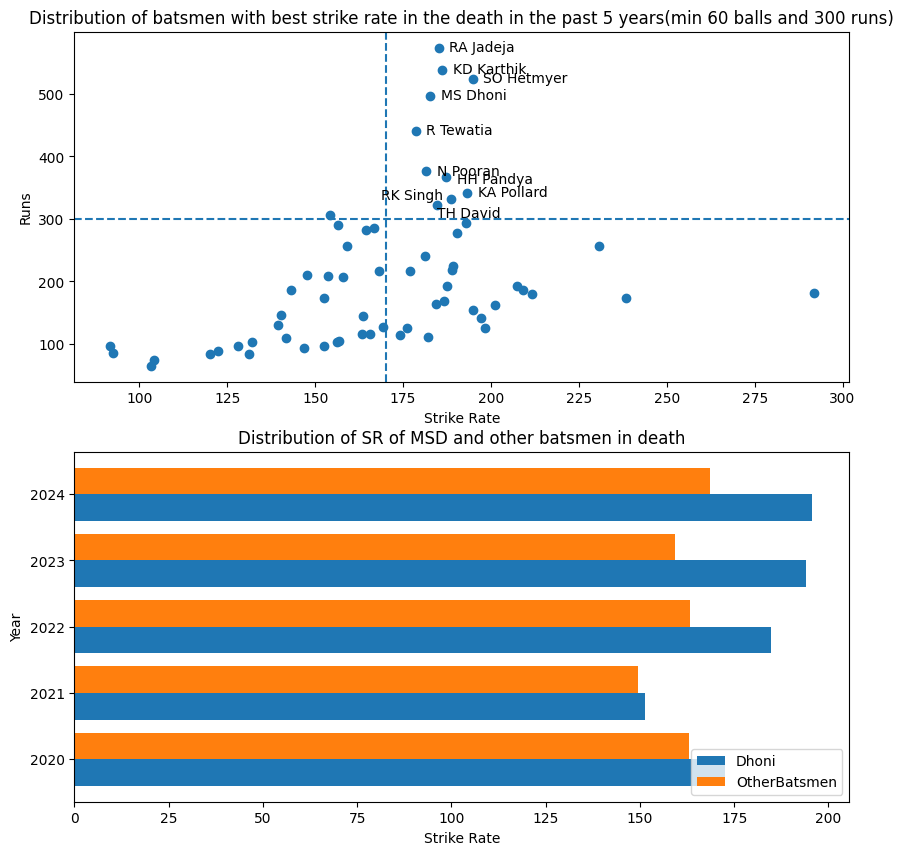

In [ ]:



import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df=pd.read_csv("all_matches.csv")
df["start_date"]=pd.to_datetime(df["start_date"])
df["year"]=df["start_date"].dt.year
df.head()
ddf16=df[(df.striker=="MS Dhoni") & (df.year>=2020) & (df.year<=2024) & (df.ball>=16.1) &(df.ball<=16.6)]
ddf.head()
ddf161=pd.DataFrame(ddf16.groupby("year")["runs_off_bat"].sum()).reset_index()
ddf161.head()
ddf162=pd.DataFrame(ddf16.groupby("year")["ball"].count()).reset_index()
ddf162.head()
ddf163=pd.merge(ddf161,ddf162,on="year")
ddf163["SR"]=round(100*(ddf163["runs_off_bat"]/ddf163["ball"]),2)
print(ddf163)
ddf=df[(df.striker=="MS Dhoni") & (df.year>=2020) & (df.year<=2024) & (df.ball>=17.1) &(df.ball<=20.0)]
ddf.head()
ddf1=pd.DataFrame(ddf.groupby("year")["runs_off_bat"].sum()).reset_index()
ddf1.head()
ddf2=pd.DataFrame(ddf.groupby("year")["ball"].count()).reset_index()
ddf2.head()
ddf3=pd.merge(ddf1,ddf2,on="year")
ddf3["SR"]=round(100*(ddf3["runs_off_bat"]/ddf3["ball"]),2)

ddf3.head()
odf=df[(df.striker!="MS Dhoni") & (df.year>=2020) & (df.year<=2024) & (df.ball>=17.1) &(df.ball<=20.0)]
odf.head()
odf1=pd.DataFrame(odf.groupby("year")["runs_off_bat"].sum()).reset_index()
odf1.head()
odf2=pd.DataFrame(odf.groupby("year")["ball"].count()).reset_index()
odf2.head()
odf3=pd.merge(odf1,odf2,on="year")
odf3["SR"]=round(100*(odf3["runs_off_bat"]/odf3["ball"]),2)
odf3.reset_index(inplace=True,drop=True)
ddf3.reset_index(inplace=True,drop=True)

print(odf3.head())
print(ddf3.head())

df=df[(df.year>=2020) & (df.year<=2024) & (df.ball>=17.1) &(df.ball<=20.0)]
df1=pd.DataFrame(df.groupby("striker")["runs_off_bat"].sum()).reset_index()
df1.head()
df2=pd.DataFrame(df.groupby("striker")["ball"].count()).reset_index()
df2.head()
df3=pd.merge(df1,df2,on="striker")
df3["SR"]=round(100*(df3["runs_off_bat"]/df3["ball"]),2)
df3=df3[df3.ball>=60]
df3.reset_index(inplace=True,drop=True)


fig,ax=plt.subplots(2,1,figsize=(10,10))
ax[0].set_title("Distribution of batsmen with best strike rate in the death in the past 5 years(min 60 balls and 300 runs)")
ax[0].set_xlabel("Strike Rate")
ax[0].set_ylabel("Runs")
ax[0].scatter(df3["SR"],df3["runs_off_bat"])
ax[0].axvline(170,ls="--")
ax[0].axhline(300,ls="--")
for i in range(len(df3)):
  if ((df3["SR"][i]>170))&(df3["runs_off_bat"][i]>300):
    if(df3["striker"][i]=="HH Pandya"):
      ax[0].text(df3["SR"][i]+3,df3["runs_off_bat"][i]-10,df3["striker"][i])
    elif(df3["striker"][i]=="RK Singh"):
      ax[0].text(df3["SR"][i]-20,df3["runs_off_bat"][i],df3["striker"][i])
    elif(df3["striker"][i]=="TH David"):
      ax[0].text(df3["SR"][i],df3["runs_off_bat"][i]-20,df3["striker"][i])
    else:
      ax[0].text(df3["SR"][i]+3,df3["runs_off_bat"][i]-6,df3["striker"][i])

val=np.arange(len(ddf3))
ax[1].set_title("Distribution of SR of MSD and other batsmen in death")
ax[1].set_ylabel("Year")
ax[1].set_xlabel("Strike Rate")
ax[1].barh(val,ddf3["SR"],0.4,label="Dhoni")
ax[1].barh(val+0.4,odf3["SR"],0.4,label="OtherBatsmen")
ax[1].set_yticks(val + 0.2)
ax[1].set_yticklabels(ddf3["year"])
ax[1].legend()
plt.show()



### Conclusion : MS Dhoni is stil the best batsman in the world when it comes to the death. From the plots we can clearly analyse that MSD has found success in the overs between 17 to 20 with his SR higher than the other batsmen though he takes time to set in the 16th over where his SR is largely below par.
###Scatter Plot further tells us that he is one among the best in ipl in the past 5 years when it comes to death with SR>170 and runs scored to be greater than 300 in between the overs of 17 to 20.
